In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("All libraries loaded successfully")

All libraries loaded successfully


In [9]:
import requests
import pandas as pd
#Fetch player data from Spring Boot API
response= requests.get("http://localhost:8080/api/players")
data= response.json()

df= pd.DataFrame(data)

print(df)

       name      game  kdRatio  winRate  id
0  Trinanda  Valorant      3.5     0.78   1
1      Adam  Valorant      2.5     0.65   2
2    Ricky       PUBG      1.8     0.52   3
3    Pandda     COD-M      3.2     0.70   4
4       Sid     CS-GO      1.2     0.48   5
5        DJ       COD      3.1     0.71   6


In [11]:
#Basic statistics
print("=== Dataset Info ===")
print(df.info())
print("\n === Basic Summary ===")
print(df.describe())
print("\n=== Games represented")
print(df['game'].value_counts())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     6 non-null      str    
 1   game     6 non-null      str    
 2   kdRatio  6 non-null      float64
 3   winRate  6 non-null      float64
 4   id       6 non-null      int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 372.0 bytes
None

 === Basic Summary ===
        kdRatio  winRate        id
count  6.000000  6.00000  6.000000
mean   2.550000  0.64000  3.500000
std    0.896103  0.11679  1.870829
min    1.200000  0.48000  1.000000
25%    1.975000  0.55250  2.250000
50%    2.800000  0.67500  3.500000
75%    3.175000  0.70750  4.750000
max    3.500000  0.78000  6.000000

=== Games represented
game
Valorant    2
PUBG        1
COD-M       1
CS-GO       1
COD         1
Name: count, dtype: int64


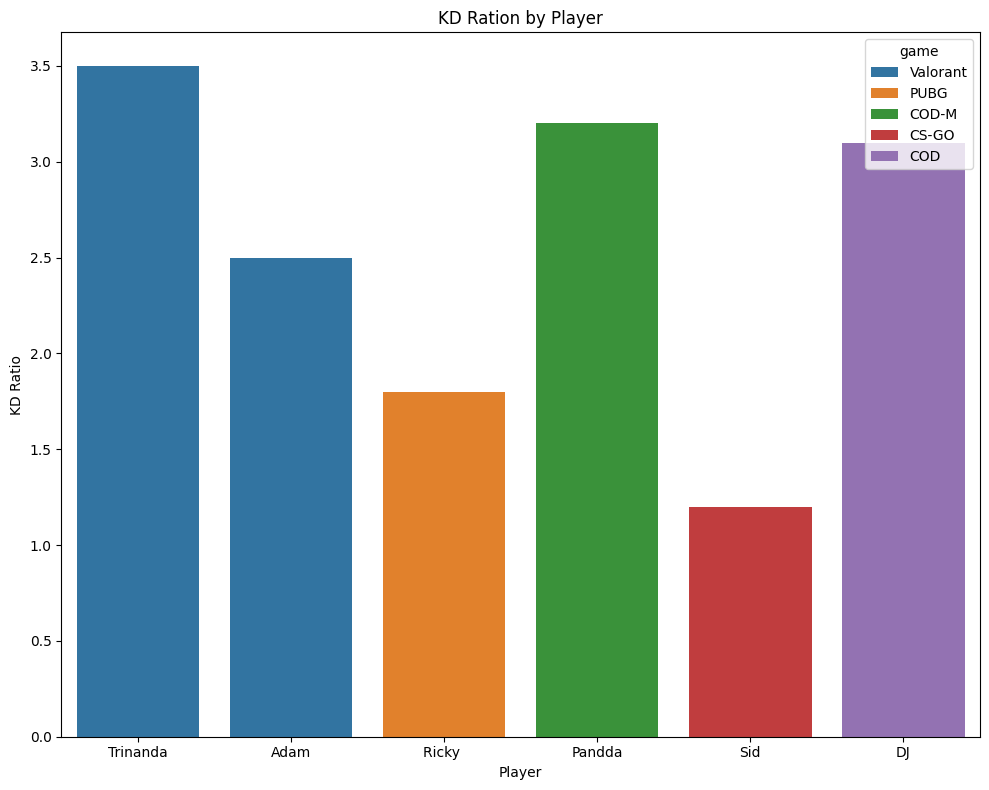

In [13]:
#KD Ratio comparison bar chart
plt.figure(figsize=(10,8))
sns.barplot(data=df,x='name', y='kdRatio',hue='game')
plt.title('KD Ration by Player')
plt.xlabel('Player')
plt.ylabel('KD Ratio')
plt.tight_layout()
plt.show()


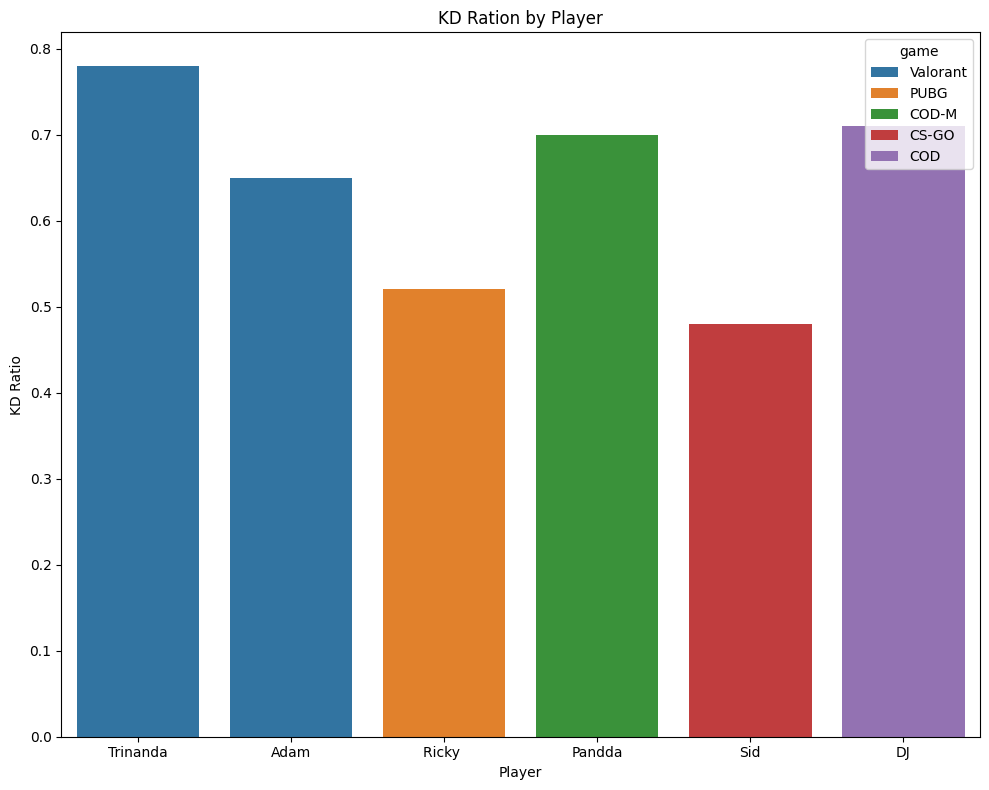

In [14]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x='name', y='winRate',hue='game')
plt.title('KD Ration by Player')
plt.xlabel('Player')
plt.ylabel('KD Ratio')
plt.tight_layout()
plt.show()

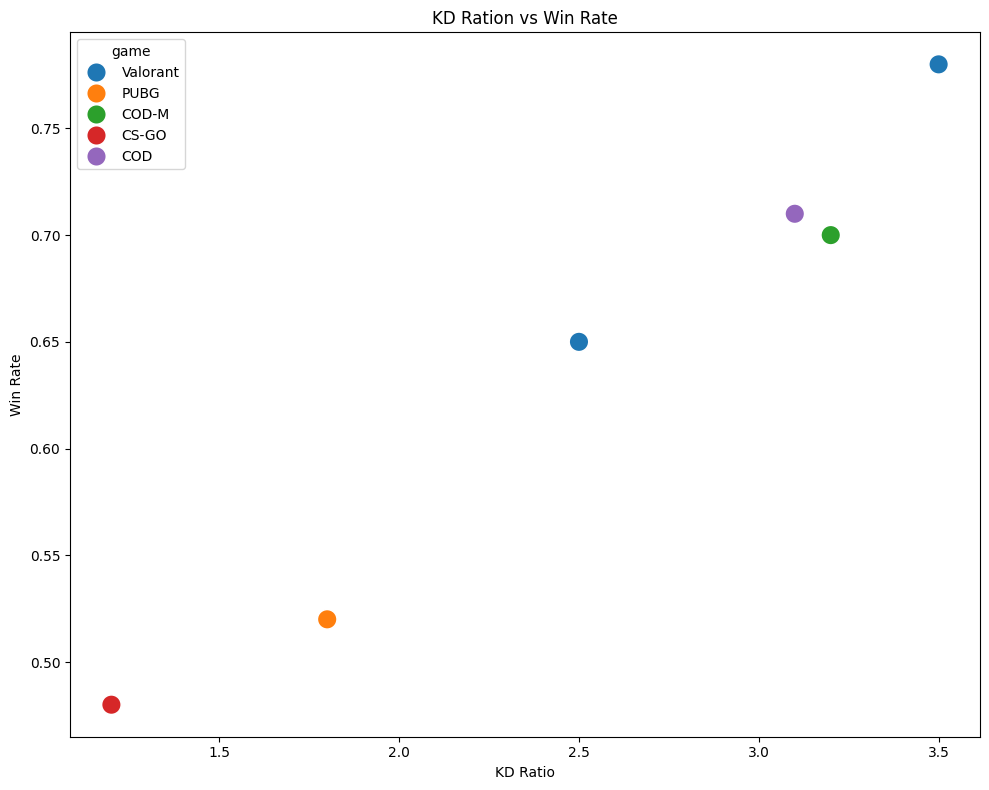

In [16]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='kdRatio', y='winRate',hue='game', s=200)
plt.title('KD Ration vs Win Rate')
plt.xlabel('KD Ratio')
plt.ylabel('Win Rate')
plt.tight_layout()
plt.show()

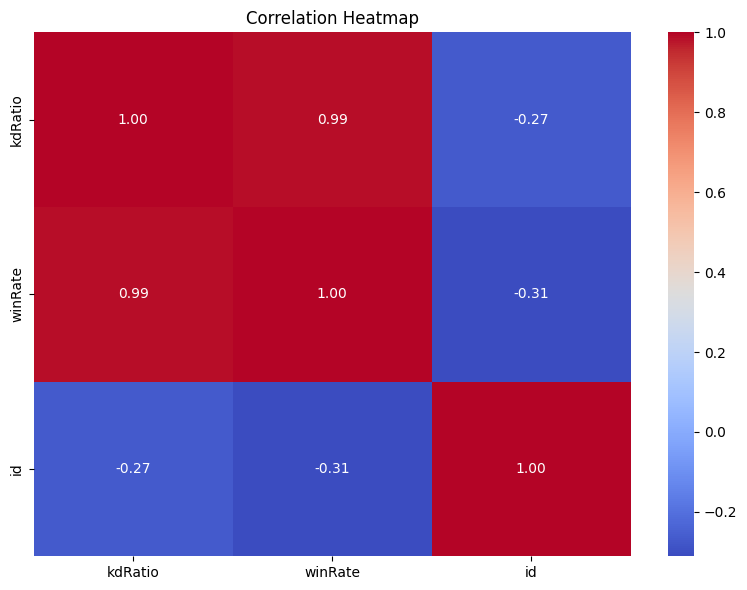

In [17]:
#Correlatiom heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['kdRatio','winRate','id']].corr(),
            annot=True,cmap='coolwarm' ,fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [22]:
print("=== Top Performer by KD Ratio ====")
print (df.loc[df['kdRatio'].idxmax(),['name','game','kdRatio']])

print("\n=== Top Performer by Win Rate ===")
print(df.loc[df['winRate'].idxmax(),['name','game','winRate']])

print("\n=== Average KD Ratio by Game ===")
print(df.groupby('game')['kdRatio'].mean().sort_values(ascending=False))



=== Top Performer by KD Ratio ====
name       Trinanda
game       Valorant
kdRatio         3.5
Name: 0, dtype: object

=== Top Performer by Win Rate ===
name       Trinanda
game       Valorant
winRate        0.78
Name: 0, dtype: object

=== Average KD Ratio by Game ===
game
COD-M       3.2
COD         3.1
Valorant    3.0
PUBG        1.8
CS-GO       1.2
Name: kdRatio, dtype: float64
